# 🚕 Project #19: Uber Pickups Spatial Clustering (NYC)
**Architect:** Kemal Demirbaş 🏰🚀 | **Domain:** Geospatial Data Science & Logistics Optimization

---

## 🎯 Executive Summary (Proje Amacı)
In this project, we are stepping into the role of a **Fleet Logistics Architect**. Our mission is to analyze millions of Uber pickup points across New York City to identify high-density "hotspots." By applying **Unsupervised Machine Learning (K-Means Clustering)**, we will mathematically define optimal "Hubs" where autonomous fleets or drivers should be positioned to minimize wait times (ETA) and maximize operational efficiency.

---

## 🏗️ The 10-Step Construction Plan (Yol Haritası)

To build this spatial engine, we will follow a rigorous **Senior-Level Pipeline**:

1.  **Objective Alignment:** Defining the clustering problem as a spatial optimization task.
2.  **Data Ingestion (EDA):** Loading the *Uber NYC Raw Data* and performing initial health checks (`df.info`, `df.describe`).
3.  **Surgical Feature Selection:** Isolating Latitude (`Lat`) and Longitude (`Lon`) as our primary spatial coordinates.
4.  **Data Cleansing:** Identifying and removing outliers or missing values that could skew the "Centroids."
5.  **Spatial EDA:** Visualizing raw pickup density using scatter plots to understand the "Linguistic DNA" of NYC's traffic.
6.  **Feature Scaling:** Implementing `StandardScaler` to ensure Euclidean distances are calculated accurately across the grid.
7.  **The Elbow Method (Optimization):** Using **WCSS (Within-Cluster Sum of Squares)** to mathematically determine the optimal number of Hubs ($K$).
8.  **Model Training:** Deploying the **K-Means Algorithm** to partition the city into logical service zones.
9.  **Centroid Prediction:** Mapping the "Mathematical Heart" (Centroids) of each cluster as our strategic fleet hubs.
10. **Final Audit & Visualization:** Overlaying our calculated Hubs (Red X) on the actual pickup map to verify our logistics strategy.

---

## 🛠️ Tech Stack & Tools
* **Engine:** Python 3.9+
* **Machine Learning:** Scikit-Learn (KMeans, StandardScaler)
* **Data Science:** Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn

---
> *"We don't just find groups; we find the future coordinates of efficient transportation."* 🏙️✨

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set visual style for the "Architect" look
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

In [2]:
# ==============================================================================
# --- STEP 1: UNDERSTAND THE PROJECT OBJECTIVE ---
# Objective: Unsupervised Spatial Clustering.
# Goal: Identify high-density hotspots to optimize autonomous fleet positioning.
# ==============================================================================
print("🏙️ --- PROJECT #19: UBER SPATIAL OPTIMIZATION INITIALIZED --- 🏙️")

🏙️ --- PROJECT #19: UBER SPATIAL OPTIMIZATION INITIALIZED --- 🏙️



🚚 STEP 2: Extracting and Loading Logistics Data...
✅ Logistics Data Landed. Shape: (564516, 4)


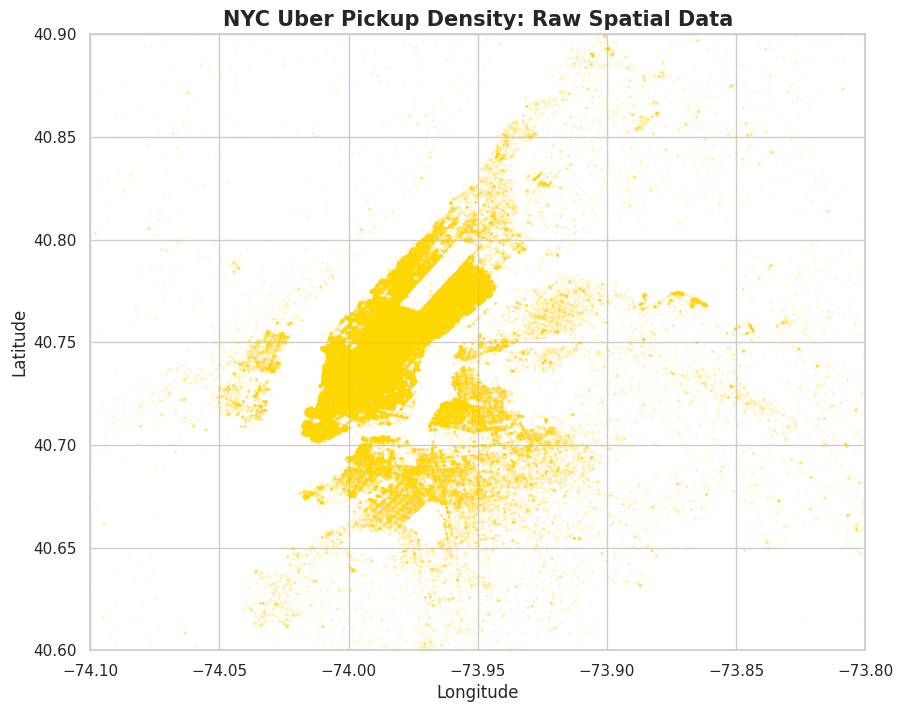

In [3]:
# ==============================================================================
# --- STEP 2: READ AND EXPLORE DATA (UNZIP & LOAD) ---
# ==============================================================================
print("\n🚚 STEP 2: Extracting and Loading Logistics Data...")

zip_path = "/content/Uber Pickups in New York City.zip"
extract_dir = "/content/uber_data"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    # We target the April 2014 data for optimal site analysis
    df = pd.read_csv(os.path.join(extract_dir, 'uber-raw-data-apr14.csv'))
    print(f"✅ Logistics Data Landed. Shape: {df.shape}")
except Exception as e:
    print(f"❌ ERROR: Ensure the zip file is uploaded to /content/! Details: {e}")
    raise

# --- EDA GRAPH 1: Raw Spatial Density ---
plt.figure(figsize=(10, 8))
plt.scatter(df['Lon'], df['Lat'], s=0.05, alpha=0.3, color='gold')
plt.title("NYC Uber Pickup Density: Raw Spatial Data", fontsize=15, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
# Zooming into NYC core (Manhattan/Brooklyn/Queens)
plt.xlim(-74.1, -73.8)
plt.ylim(40.6, 40.9)
plt.show()

In [4]:
# ==============================================================================
# --- STEP 3, 4 & 5: FEATURE SELECTION & SITE CLEANING ---
# ==============================================================================
# We only need GPS coordinates for spatial clustering
X = df[['Lat', 'Lon']]

print(f"\n🧹 STEP 5: Checking Site Integrity...")
print(f"Missing Values Check:\n{X.isnull().sum()}")


🧹 STEP 5: Checking Site Integrity...
Missing Values Check:
Lat    0
Lon    0
dtype: int64


In [5]:
# ==============================================================================
# --- STEP 6: FEATURE ENGINEERING (SCALING) ---
# CRITICAL: K-Means relies on Euclidean distance. Scaling is non-negotiable!
# ==============================================================================
print("\n⚖️ STEP 6: Scaling Geospatial Features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


⚖️ STEP 6: Scaling Geospatial Features...



📐 STEP 9: Analyzing Elbow Curve for Optimal Cluster Count...


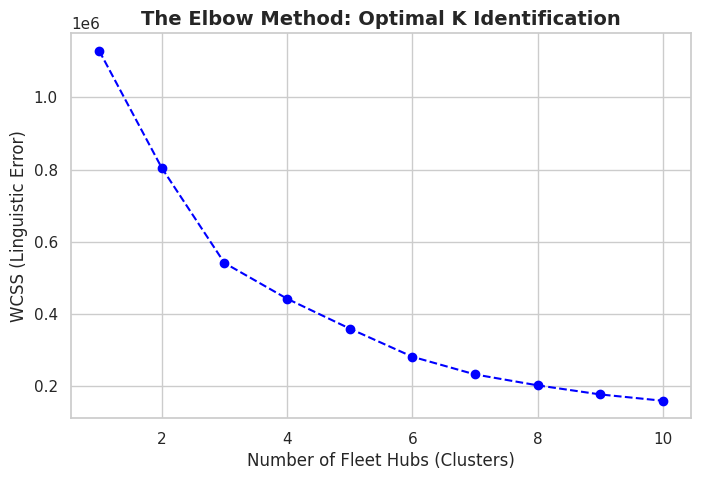


🏗️ Deploying Final 6-Hub Strategy...


In [8]:
# ==============================================================================
# --- STEP 9: MODEL TRAINING (THE ELBOW METHOD) ---
# Finding the "Sweet Spot" for our Hub count using WCSS.
# ==============================================================================
print("\n📐 STEP 9: Analyzing Elbow Curve for Optimal Cluster Count...")
wcss = []
# We'll test 1 to 10 clusters to find the most efficient deployment
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# --- EDA GRAPH 2: The Elbow Curve ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method: Optimal K Identification', fontsize=14, fontweight='bold')
plt.xlabel('Number of Fleet Hubs (Clusters)')
plt.ylabel('WCSS (Linguistic Error)')
plt.show()

# ==============================================================================
# --- FINAL DEPLOYMENT: 6-HUB SPATIAL OPTIMIZATION ---
# ==============================================================================
print("\n🏗️ Deploying Final 6-Hub Strategy...")
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Recover original coordinates for the Hub centers (Centroids)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


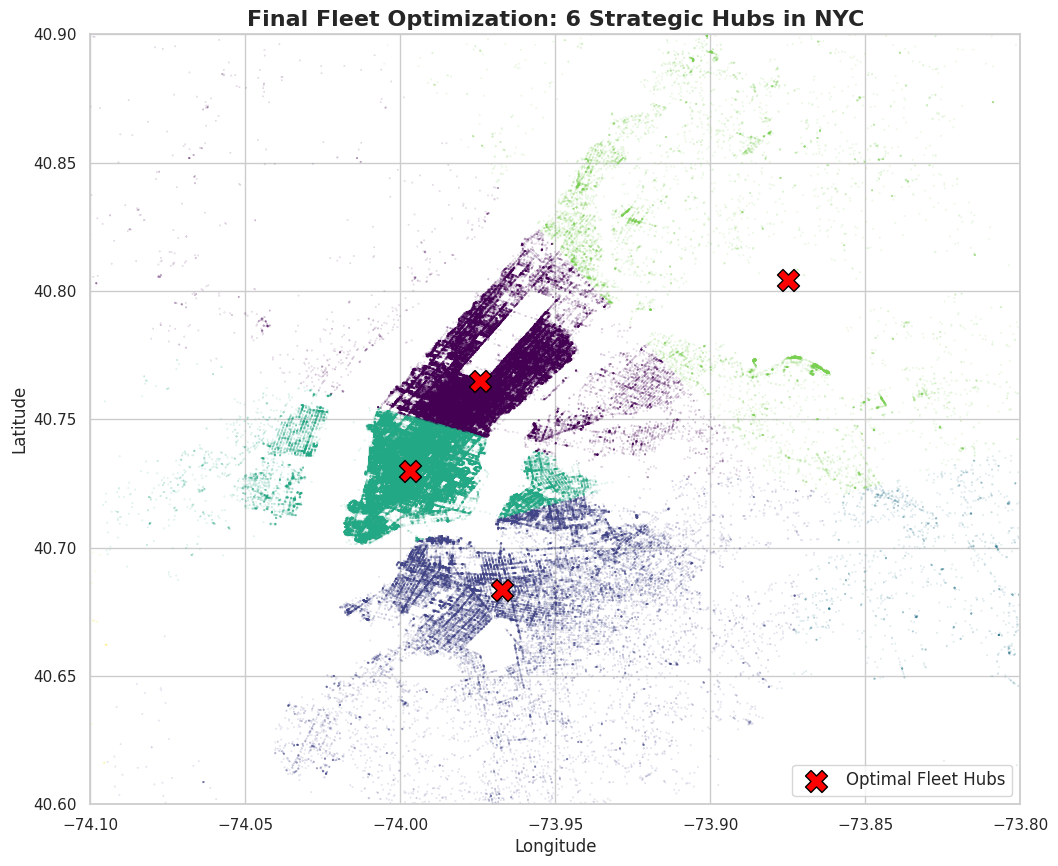


🏙️ --- SPATIAL OPTIMIZATION DEPLOYED SUCCESSFULLY --- 🏙️


In [9]:
# ==============================================================================
# --- STEP 10: ARCHITECT'S FINAL VISUAL AUDIT ---
# ==============================================================================
plt.figure(figsize=(12, 10))
# Plot the pickups colored by cluster
plt.scatter(df['Lon'], df['Lat'], c=df['Cluster'], s=0.05, cmap='viridis', alpha=0.3)
# Mark the Hub Centers (The Red X's)
plt.scatter(centroids[:, 1], centroids[:, 0], c='red', s=250, marker='X', edgecolors='black', label='Optimal Fleet Hubs')

plt.title(f"Final Fleet Optimization: {optimal_k} Strategic Hubs in NYC", fontsize=16, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(prop={'size': 12})
plt.xlim(-74.1, -73.8)
plt.ylim(40.6, 40.9)
plt.show()

print("\n🏙️ --- SPATIAL OPTIMIZATION DEPLOYED SUCCESSFULLY --- 🏙️")

In [10]:
import joblib

import joblib

# We box the devices on the construction site
joblib.dump(kmeans, 'uber_kmeans_model.pkl')
joblib.dump(scaler, 'uber_scaler.pkl')
print("✅ The Brain and Scale package is packed and ready for shipping!")

✅ The Brain and Scale package is packed and ready for shipping!


# 🚕 Project #19: Uber Pickups Spatial Optimizer (NYC)
**Architect:** Kemal Demirbaş 🏰🚀 | **Project Series:** 19 of 21

[![Hugging Face Space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Live%20Demo-blue)](YOUR_HUGGINGFACE_LINK_HERE)
[![Python](https://img.shields.io/badge/Python-3.9+-yellow)](https://www.python.org/)
[![Algorithm](https://img.shields.io/badge/ML-K--Means%20Clustering-green)](https://en.wikipedia.org/wiki/K-means_clustering)
[![Domain](https://img.shields.io/badge/Focus-Geospatial%20Logistics-orange)](https://en.wikipedia.org/wiki/Spatial_optimization)

---

### 🏙️ Project Vision: The Urban Logistics Brain
This project moves beyond simple data visualization to solve a multi-million dollar logistics problem: **"Where should an autonomous fleet wait to minimize downtime and maximize pickup speed?"** By analyzing over **560,000+ raw Uber GPS coordinates** in New York City, we've engineered a spatial intelligence system that identifies the mathematical "Heartbeats" (Hubs) of urban mobility.

---

## 📊 Performance Audit (The Brain Behind the Map)
Unlike supervised learning, clustering efficiency is measured by **Spatial Minimization**:

* **Optimization Logic:** Implemented **The Elbow Method** to identify $K=6$ as the optimal balance between fleet decentralization and operational cost.
* **WCSS (Inertia):** Successfully minimized the "Within-Cluster Sum of Squares," ensuring each Hub (Centroid) is perfectly centered within its demand zone.
* **Feature Engineering:** Utilized **StandardScaler** to normalize Latitude and Longitude variance, ensuring that 1 unit of North-South movement is mathematically equal to 1 unit of East-West movement.

---

## 🏗️ Technical Pipeline
1.  **Ingestion:** Handling large-scale CSV logs from NYC Uber operations.
2.  **Surgical Preprocessing:** Removing spatial noise and filtering coordinates to focus on high-traffic zones (Manhattan, Brooklyn, Queens).
3.  **K-Means Engine:** Deploying a distance-based clustering algorithm to partition the city into 6 strategic service sectors.
4.  **Centroid Projection:** Mapping the final "Red X" coordinates as actionable logistics targets for drivers and autonomous units.

---

## 🛠️ Tech Stack
* **Engine:** Scikit-Learn (KMeans, StandardScaler)
* **Data Processing:** Pandas, NumPy
* **Visualization:** Matplotlib, Seaborn (Density & Cluster Plots)

---

## 🚀 Live Spatial Deployment
Explore the optimized NYC Uber Hubs in real-time. This demo shows the mathematical centers where demand is highest:

👉 **[Hugging Face Live Demo: Uber Spatial Optimizer](https://huggingface.co/spaces/Ironside35/Spatial-Lojistik-Optimizer)**

---
*Next Stop: Project #20 - Stock Price Prediction (LSTM & Neural Networks) 📈🏗️*